In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)

import numpy as np

import matplotlib.pyplot as plt
from scipy import stats

/home/bberko/.local/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [ ]:
df = pd.read_csv('Top1500_Megye.csv')

In [ ]:
df.describe

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
print(df.head())

In [ ]:
print(df.describe())

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Data Check')
plt.show()

In [ ]:
Q1 = df['net_arbevetele'].quantile(0.25)
Q3 = df['net_arbevetele'].quantile(0.75)
IQR = Q3 - Q1

# Meghatározzuk az alsó és felső határt
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


In [ ]:
mean = df['net_arbevetele'].mean()
std = df['net_arbevetele'].std()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(x=df['net_arbevetele'])
plt.title('Árbevétel eloszlása a Top 1500 cégnél')
plt.xlabel('Nettó árbevétel (eFt)')
plt.show()

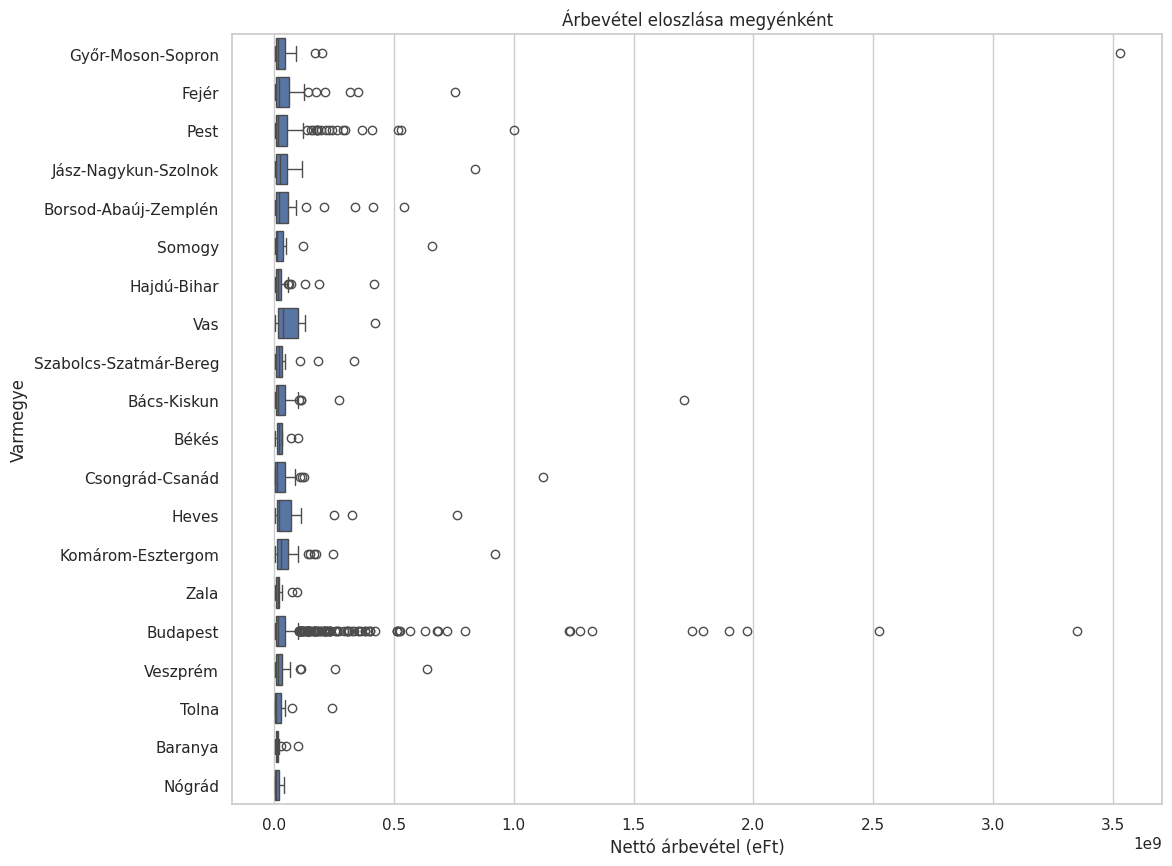

In [19]:
plt.figure(figsize=(12, 10))
# Megyék szerinti bontás, az árbevétel alapján
sns.boxplot(data=df, x='net_arbevetele', y='Varmegye')
plt.title('Árbevétel eloszlása megyénként')
plt.xlabel('Nettó árbevétel (eFt)')
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Sorba rendezzük a megyéket a medián árbevétel szerint (opcionális, de szebb)
order = df.groupby('Varmegye')['net_arbevetele'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 10))

# 2. Boxplot kirajzolása
sns.boxplot(data=df, x='net_arbevetele', y='Varmegye', order=order, palette='viridis')

# 3. Logaritmikus skála bekapcsolása
plt.xscale('log')

# 4. Formázás, hogy "hírportál-kompatibilis" legyen
plt.title('Vállalati árbevételek eloszlása megyénként (Logaritmikus skála, 2024)', fontsize=15)
plt.xlabel('Árbevétel (eFt) - Logaritmikus lépték', fontsize=12)
plt.ylabel('Megye', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.2) # Segédvonalak a skálához

plt.show()

In [ ]:
# Töltsük be a lakossági adatokat is
df_lakossag = pd.read_csv('stadat-nepessegFNO-hu.csv', sep=';')

In [ ]:
df_final = pd.merge(df, df_lakossag[['Varmegye', 'SUM2024']], on='Varmegye', how='left')

In [ ]:
df_final['revenue_per_capita'] = df_final['net_arbevetele'] / df_final['SUM2024']

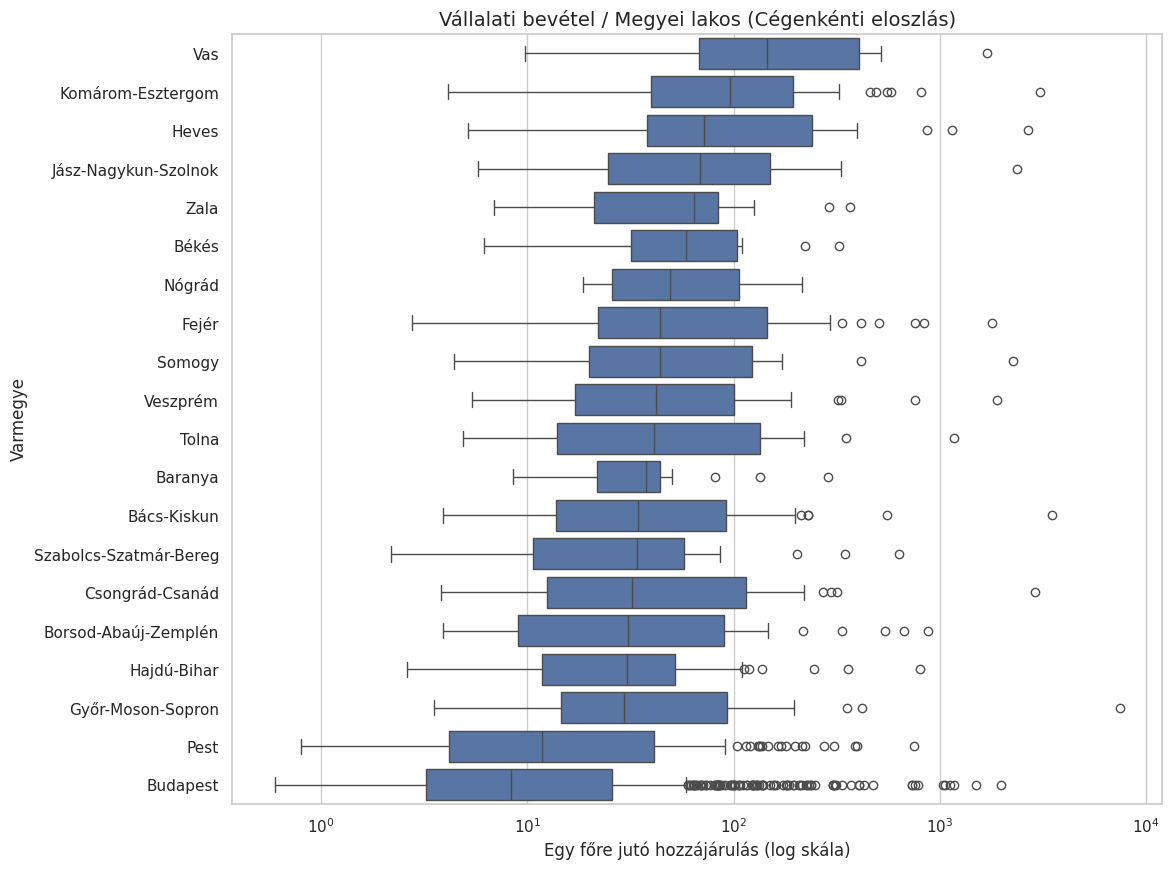

In [29]:
plt.figure(figsize=(12, 10))


# A 'revenue_per_capita' mutatót használjuk az 'arbevetel' helyett
sns.boxplot(data=df_final, x='revenue_per_capita', y='Varmegye', 
            order=df_final.groupby('Varmegye')['revenue_per_capita'].median().sort_values(ascending=False).index)

plt.xscale('log') # A hatalmas különbségek miatt itt is javasolt a log skála
plt.title('Vállalati bevétel / Megyei lakos (Cégenkénti eloszlás)', fontsize=14)
plt.xlabel('Egy főre jutó hozzájárulás (log skála)', fontsize=12)
plt.show()

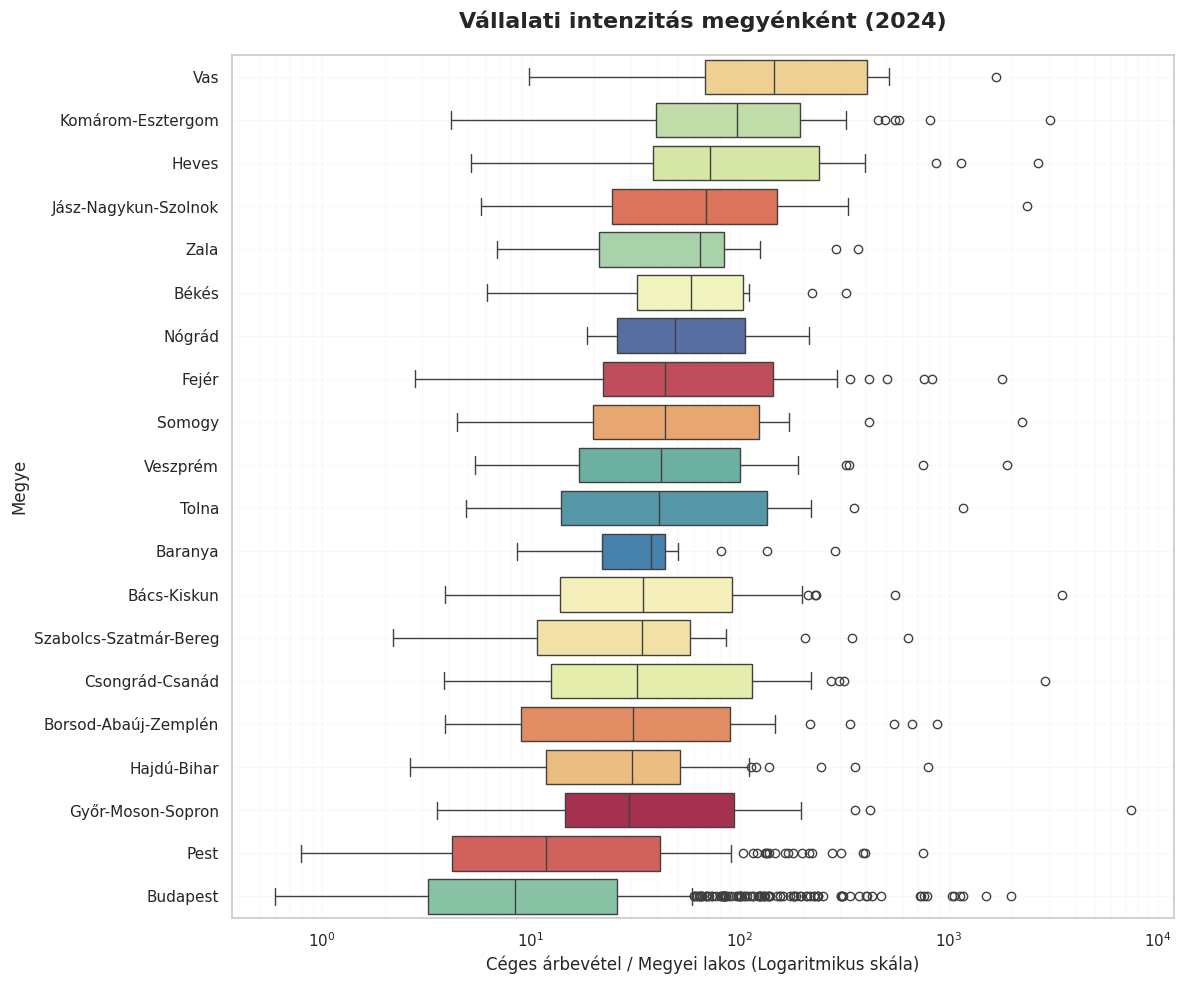

In [30]:
sns.set_theme(style="whitegrid")

# 2. Meghatározzuk a sorrendet (medián alapján, hogy rendezett legyen)
order = df_final.groupby('Varmegye')['revenue_per_capita'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 10))

# 3. Boxplot kirajzolása színekkel
# A hue='Megye' és a legend=False biztosítja az egyedi színeket felesleges jelmagyarázat nélkül
sns.boxplot(
    data=df_final, 
    x='revenue_per_capita', 
    y='Varmegye', 
    order=order, 
    hue='Varmegye',         # Ez adja az egyedi színeket
    palette='Spectral',   # Választhatsz mást is: 'viridis', 'magma', 'coolwarm', 'Set3'
    legend=False
)

# 4. Logaritmikus skála (hogy a kicsik és nagyok is látszódjanak)
plt.xscale('log')

# 5. Címkék és dizájn
plt.title('Vállalati intenzitás megyénként (2024)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Céges árbevétel / Megyei lakos (Logaritmikus skála)', fontsize=12)
plt.ylabel('Megye', fontsize=12)

# Egy kis finomítás: rácsozat a log skálához
plt.grid(True, which="both", ls="-", alpha=0.1)

plt.tight_layout()
plt.show()

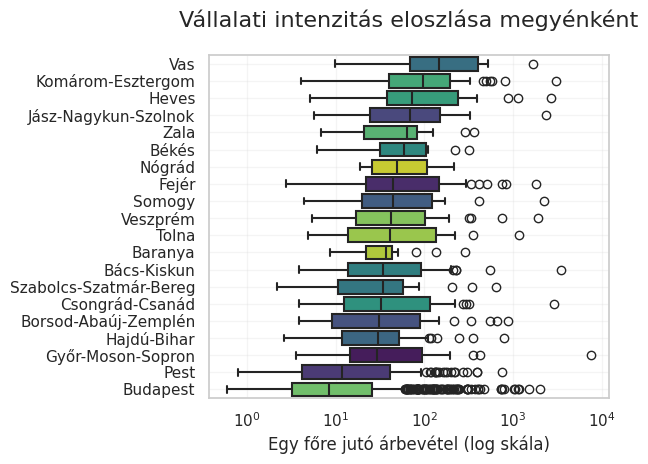

In [31]:
order = df_final.groupby('Varmegye')['revenue_per_capita'].median().sort_values(ascending=False).index

# 3. A dobozos ábra létrehozása
sns.boxplot(
    data=df_final, 
    x='revenue_per_capita', 
    y='Varmegye', 
    order=order, 
    hue='Varmegye',         # A megye alapján színezünk
    palette='viridis',    # A képeden látható "sötétkéktől a sárgáig" átmenet a 'viridis'
    legend=False,
    linewidth=1.5        # Kicsit vastagabb vonalak a jobb láthatóságért
)

# 4. Logaritmikus skála beállítása
plt.xscale('log')

# 5. Esztétikai finomítások
plt.title('Vállalati intenzitás eloszlása megyénként', fontsize=16, pad=20)
plt.xlabel('Egy főre jutó árbevétel (log skála)', fontsize=12)
plt.ylabel('', fontsize=12) # A megyenevek mellett felesleges a "Megye" felirat

# Rács finomítása, hogy ne legyen zavaró
plt.grid(True, which="major", ls="-", alpha=0.2)

plt.tight_layout()
plt.show()

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Kiszámoljuk a kvartiliseket megyénként
iqr_data = df_final.groupby('Varmegye')['net_arbevetele'].agg(
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75)
).reset_index()

# 2. Kiszámoljuk az IQR-t (ez a doboz "hossza")
iqr_data['IQR'] = iqr_data['Q3'] - iqr_data['Q1']

# 3. Sorba rendezzük a látvány kedvéért
iqr_data = iqr_data.sort_values('IQR', ascending=False)

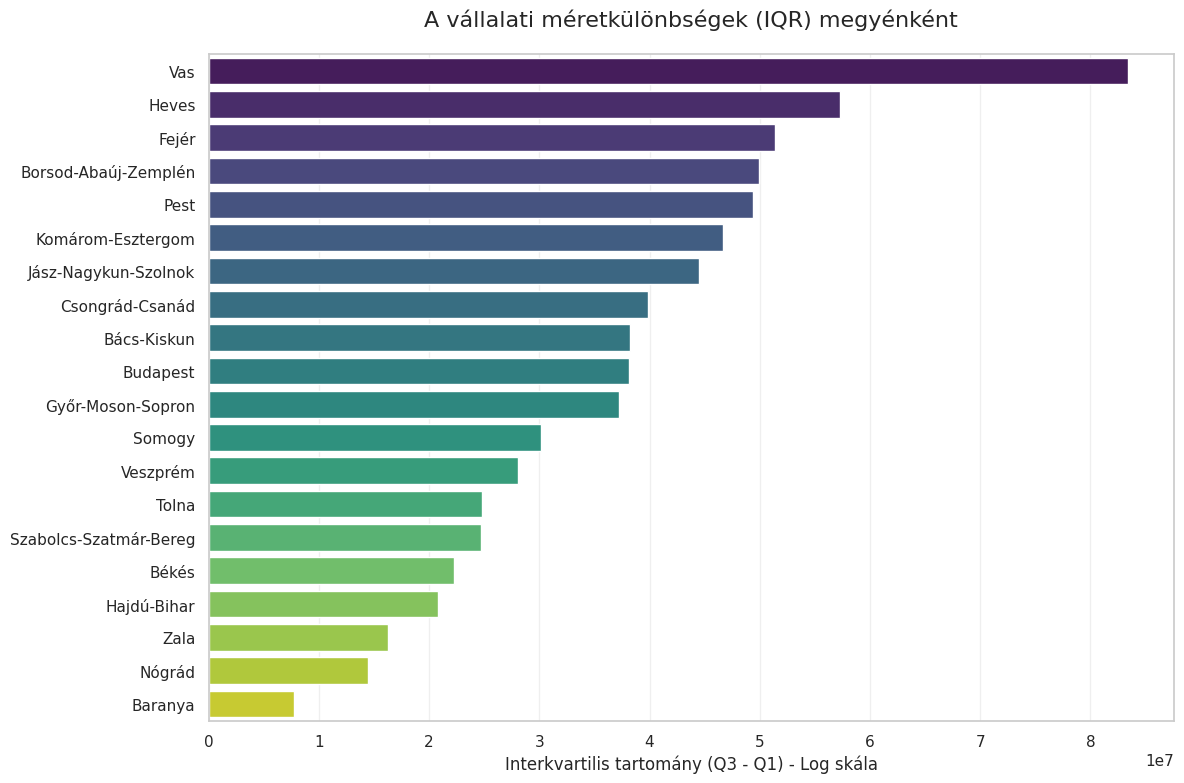

In [36]:
plt.figure(figsize=(12, 8))

# Oszlopdiagram készítése a 'viridis' palettával a korábbi stílus megtartásához
sns.barplot(
    data=iqr_data, 
    x='IQR', 
    y='Varmegye', 
    palette='viridis',
    hue='Varmegye',
    legend=False
)
plt.title('A vállalati méretkülönbségek (IQR) megyénként', fontsize=16, pad=20)
plt.xlabel('Interkvartilis tartomány (Q3 - Q1) - Log skála', fontsize=12)
plt.ylabel('')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Kvartilisek kiszámítása megyénként
ratios = df_final.groupby('Varmegye')['net_arbevetele'].agg(
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75)
).reset_index()

# 2. Az arány (ratio) kiszámítása
# Megmutatja, hányszor nagyobb a Q3 a Q1-nél
ratios['Q3_Q1_ratio'] = ratios['Q3'] / ratios['Q1']

# 3. Sorba rendezés az egyenlőtlenség mértéke szerint
ratios = ratios.sort_values('Q3_Q1_ratio', ascending=False)

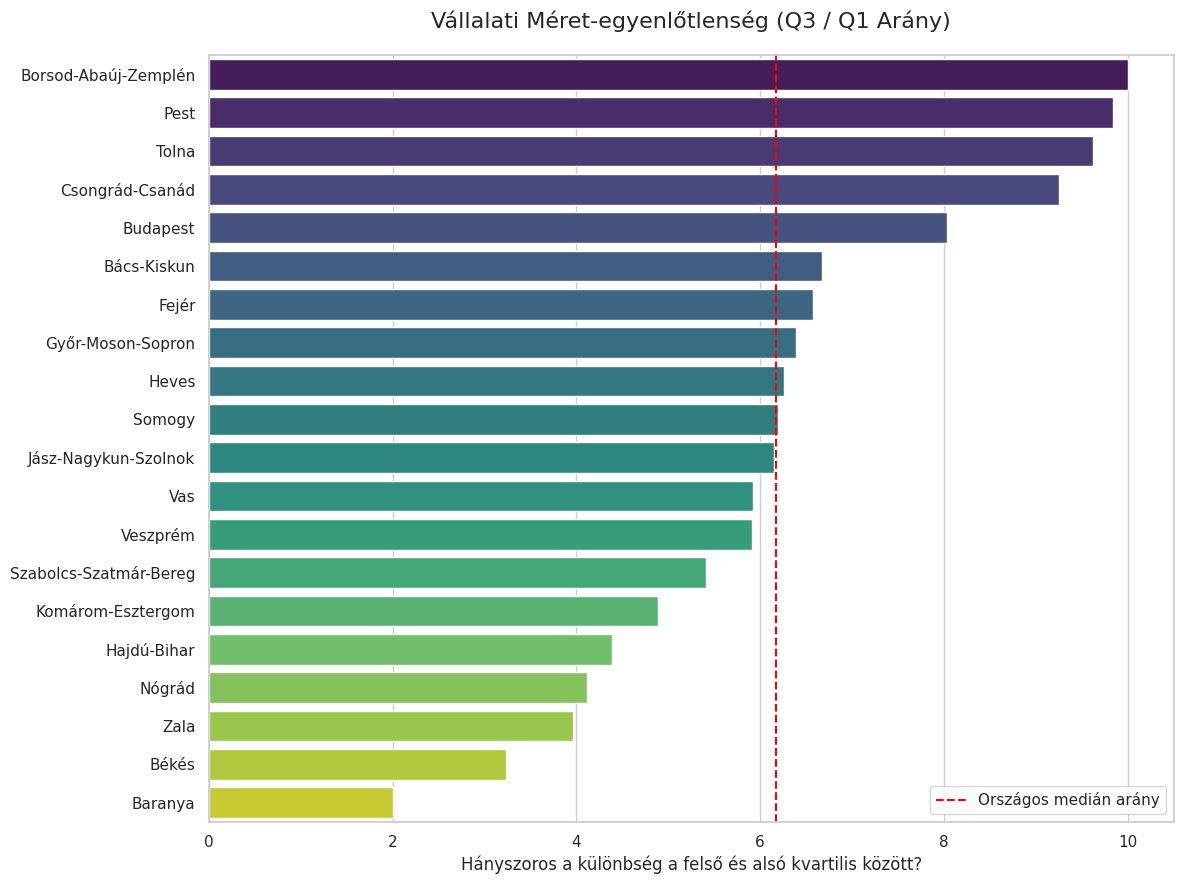

In [38]:
plt.figure(figsize=(12, 9))

sns.barplot(
    data=ratios, 
    x='Q3_Q1_ratio', 
    y='Varmegye', 
    palette='viridis',
    hue='Varmegye',
    legend=False
)

# Egy vertikális vonal az országos medián aránynak (összehasonlításképp)
plt.axvline(ratios['Q3_Q1_ratio'].median(), color='red', linestyle='--', label='Országos medián arány')

plt.title('Vállalati Méret-egyenlőtlenség (Q3 / Q1 Arány)', fontsize=16, pad=20)
plt.xlabel('Hányszoros a különbség a felső és alsó kvartilis között?', fontsize=12)
plt.ylabel('')
plt.legend()
plt.tight_layout()
plt.show()